# Aprendizagem por Reforço

Este notebook Jupyter funciona como material de suporte para a parte da matéria sobre aprendizagem por Reforço. Este notebook faz uso das implementações do módulo `rl.py`. Utilizámos também a implementação de MDPs no módulo `mdp.py` para testar os nossos agentes.

É importante se já tiver lido o Jupyter Notebook que trata do processo de decisão de Markov.

Vamos importar tudo do módulo `rl`. Pode ser útil visualizar a origem de algumas das nossas implementações.

In [ ]:
from reinforcement_learning import *

## ÍNDICE

* Visão geral

* Aprendizagem por reforço passivo

    - Estimação de utilidade direta (DUE)
    - Programação dinâmica adaptativa (ADP)
    - Agente de diferença temporal (TD)

* Aprendizagem por reforço ativo

    - Aprendizagem Q-Learning

## VISÃO GERAL

Antes de começarmos a brincar com as implementações reais, vamos rever algumas coisas sobre o RL.

1. A aprendizagem por reforço preocupa-se com a forma como os agentes de software devem tomar ações num ambiente para maximizar alguma noção de recompensa cumulativa.

2. A aprendizagem por reforço difere da aprendizagem supervisionada padrão porque os pares corretos de entrada/saída nunca são apresentados, nem as ações subóptimas são corrigidas explicitamente. Além disso, existe um foco no desempenho online, que envolve encontrar um equilíbrio entre a **exploração** (de território desconhecido) e o **aproveitamento** (de conhecimento atual).

Em síntese, temos uma sequência de transições de ações de estado com recompensas associadas a alguns estados.

O nosso objetivo é encontrar a política ótima $\pi$ que nos diga qual a ação a tomar em cada estado.

## APRENDIZAGEM POR REFORÇO PASSIVA

Na Aprendizagem por Reforço passiva, o agente segue uma política fixa $\pi$. A aprendizagem passiva tenta avaliar a política dada $\pi$ - sem qualquer conhecimento da função de recompensa $R(s)$ e do modelo de transição $P(s'\ |\ s, a)$.

Isto é normalmente feito por um método de **estimativa de utilidade**. O agente tenta aprender diretamente a utilidade de cada estado que resultaria do cumprimento da política.

Note-se que a cada passo, ele tem de *perceber* a recompensa e o estado - e não tem conhecimento global dos mesmos. Assim, se um determinado conjunto de ações oferecer uma probabilidade muito baixa de atingir algum estado $s_+$ - o agente pode nunca se aperceber da recompensa $R(s_+)$.

Considere uma situação em que um agente recebe uma política a seguir. Assim, a qualquer momento ele apenas conhece o seu estado atual, a sua recompensa atual e a próxima ação que deve tomar. Esta ação pode levá-lo a mais do que um estado, com probabilidades diferentes.

Para uma série de acções dadas por $\pi$, a utilidade estimada $U$: $$ U^{\pi}(s) = E(\sum_{t=0}^\infty \gamma^t R^t(s'))$$ Ou o valor esperado das recompensas descontadas somadas até ao fim.

Com base neste conceito, discutimos três métodos de estimativa de utilidade:

1. **Estimativa de utilidade direta (DUE)**

O primeiro método, mais ingénuo, de estimativa de utilidade provém da interpretação mais simples da definição acima.

Construímos um agente que segue a política até atingir o estado terminal. A cada passo, regista o seu estado atual, recompensa. Quando atinge o estado terminal, pode estimar a utilidade de cada estado para *essa* iteração, bastando para isso somar as recompensas descontadas desse estado para o terminal.

Agora ele pode executar esta 'simulação' $n$ vezes e calcular a utilidade média de cada estado. Se um estado ocorrer mais do que uma vez numa simulação, ambos os valores de utilidade serão contados separadamente.

Note-se que este método pode ser proibitivamente lento para espaços de estado muito grandes.

Além disso, **não presta atenção à probabilidade de transição $P(s'\ |\ s, a)$.** Perde informação que é capaz de recolher (por exemplo, ao registar o número de vezes que uma ação de um estado levou a outro estado).

O próximo método aborda este problema.

2. **Programação Dinâmica Adaptativa (ADP)**

Este método faz uso do conhecimento do estado passado $s$, da acção $a$ e do novo estado percebido $s'$ para estimar a probabilidade de transição $P(s'\ |\ s,a)$.

Fá-lo através da simples contagem de novos estados resultantes de estados e ações anteriores.

O programa executa a política várias vezes, mantendo o controlo de:

- cada ocorrência do estado $s$ e da ação recomendada pela política $a$ em $N_{sa}$
- cada ocorrência de $s'$ resultante de $a$ em $s$ em $N_{s'|sa}$.

Pode, portanto, estimar $P(s'\ |\ s,a)$ como $N_{s'|sa}/N_{sa}$, que no limite de infinitas tentativas, irá convergir para o valor verdadeiro.

Usando as probabilidades de transição assim estimadas, pode aplicar `POLICY-EVALUATION` para estimar as utilidades $U(s)$ usando propriedades de convergência das funções de Bellman.

3. **Aprendizagem de diferença temporal (TD)**

Em vez de construir explicitamente o modelo de transição $P$, o modelo de diferença temporal faz uso da proximidade esperada entre as utilidades de dois estados consecutivos $s$ e $s'$.

Para a transição $s$ para $s'$, a actualização escreve-se como:

$$U^{\pi}(s) \leftarrow U^{\pi}(s) + \alpha \left( R(s) + \gamma U^{\pi}(s') - U^{\pi}(s) \right)$$

Este modelo incorpora implicitamente as probabilidades de transição ao ser ponderado para cada estado pelo número de vezes que é atingido a partir do estado actual. Assim, ao longo de várias iterações, converge de forma semelhante às equações de Bellman.

A vantagem do modelo de aprendizagem TD é a sua computação relativamente simples em cada etapa, em vez de ter de monitorizar várias contagens.

Para $n_s$ estados e $n_a$ ações, o modelo ADP teria $n_s \times n_a$ números $N_{sa}$ e $n_s^2 \times n_a$ números $N_{s'|sa}$ para monitorizar.

O modelo TD deve manter registo apenas uma utilidade $U(s)$ para cada estado.

#### Demonstrating Passive agents

Passive agents are implemented in `rl.py` as various `Agent-Class`es.

To demonstrate these agents, we make use of the `GridMDP` object from the `MDP` module. `sequential_decision_environment` is similar to that used for the `MDP` notebook but has discounting with $\gamma = 0.9$.

The `Agent-Program` can be obtained by creating an instance of the relevant `Agent-Class`. The `__call__` method allows the `Agent-Class` to be called as a function. The class needs to be instantiated with a policy ($\pi$) and an `MDP` whose utility of states will be estimated.

In [ ]:
from mdp import sequential_decision_environment

O `sequential_decision_environment` é um objeto GridMDP, como se mostra abaixo.

As recompensas são **+1** e **-1** nos estados terminais, e **-0,04** nos restantes.

<img src="images/mdp.png">

Definimos agora ações e uma política semelhante à uma que era ótima quando antes R = -0.04.

In [ ]:
# Action Directions
north = (0, 1)
south = (0,-1)
west = (-1, 0)
east = (1, 0)

policy = {
    (0, 2): east,  (1, 2): east,  (2, 2): east,   (3, 2): None,
    (0, 1): north,                (2, 1): north,  (3, 1): None,
    (0, 0): north, (1, 0): west,  (2, 0): west,   (3, 0): west, 
}


### Agente de Estimativa de Utilidade Directa (DUE)

A classe `PassiveDEUAgent` no módulo `rl` implementa o Programa de agentes descrito.

`PassiveDEUAgent` soma as recompensas para encontrar a utilidade estimada para cada estado.

Por isso, requer a execução de uma série de iterações.

In [ ]:
%psource PassiveDUEAgent

In [7]:
DUEagent = PassiveDUEAgent(policy, sequential_decision_environment)
for i in range(200):
    run_single_trial(DUEagent, sequential_decision_environment)
    DUEagent.estimate_U()



The calculated utilities are:

In [8]:
print('\n'.join([str(k)+':'+str(v) for k, v in DUEagent.U.items()]))

(0, 1):0.8218224996131858
(1, 2):0.9119714353657651
(0, 0):0.7741914358611683
(0, 2):0.8681587399584505
(2, 2):0.9574121093562162
(3, 2):1.0
(1, 0):0.7266684532165527
(2, 1):0.8816703128814698
(3, 1):-1.0


### Agente de Programação Dinâmica Adaptativa (ADP)

A classe `PassiveADPAgent` no módulo `rl` implementa o Programa Agente descrito.

`PassiveADPAgent` utiliza transições de estado e contagens de ocorrências para estimar $P$ e depois $U$.

Aceda à fonte abaixo para entender o agente.

In [9]:
%psource PassiveADPAgent

class PassiveADPAgent:
    """
    [Figure 21.2]
    Passive (non-learning) agent that uses adaptive dynamic programming
    on a given MDP and policy.

    import sys
    from mdp import sequential_decision_environment
    north = (0, 1)
    south = (0,-1)
    west = (-1, 0)
    east = (1, 0)
    policy = {(0, 2): east, (1, 2): east, (2, 2): east, (3, 2): None, (0, 1): north, (2, 1): north,
              (3, 1): None, (0, 0): north, (1, 0): west, (2, 0): west, (3, 0): west,}
    agent = PassiveADPAgent(policy, sequential_decision_environment)
    for i in range(100):
        run_single_trial(agent,sequential_decision_environment)

    agent.U[(0, 0)] > 0.2
    True
    agent.U[(0, 1)] > 0.2
    True
    """

    class ModelMDP(MDP):
        """Class for implementing modified Version of input MDP with
        an editable transition model P and a custom function T."""

        def __init__(self, init, actlist, terminals, gamma, states):
            super().__init__(init, actlist, termin

We instantiate a `PassiveADPAgent` below with the `GridMDP` shown and train it over 200 iterations. The `rl` module has a simple implementation to simulate iterations. The function is called **run_single_trial**.

In [10]:
ADPagent = PassiveADPAgent(policy, sequential_decision_environment)
for i in range(200):
    run_single_trial(ADPagent, sequential_decision_environment)

The calculated utilities are:

In [11]:
print('\n'.join([str(k)+':'+str(v) for k, v in ADPagent.U.items()]))

(0, 0):0.7099999999938595
(0, 1):0.7645999999991074
(1, 2):0.8717999999999999
(2, 1):0.46380000000000005
(3, 1):-1.0
(2, 0):0.0
(3, 0):0.0
(0, 2):0.8135655172412286
(2, 2):0.9212
(1, 0):0.657826086942112
(3, 2):1.0


### Agente de Diferença Temporal Passiva (TD)

 `PassiveTDAgent` utiliza diferenças temporais para aprender estimativas de utilidade.
 
 Aprendemos a diferença entre os estados e fazemos o backup dos valores para os estados anteriores.
 
 Vamos dar uma vista de olhos à fonte antes de ver alguns exemplos de utilização.

In [12]:
%psource PassiveTDAgent

class PassiveTDAgent:
    """
    [Figure 21.4]
    The abstract class for a Passive (non-learning) agent that uses
    temporal differences to learn utility estimates. Override update_state
    method to convert percept to state and reward. The mdp being provided
    should be an instance of a subclass of the MDP Class.

    import sys
    from mdp import sequential_decision_environment
    north = (0, 1)
    south = (0,-1)
    west = (-1, 0)
    east = (1, 0)
    policy = {(0, 2): east, (1, 2): east, (2, 2): east, (3, 2): None, (0, 1): north, (2, 1): north,
              (3, 1): None, (0, 0): north, (1, 0): west, (2, 0): west, (3, 0): west,}
    agent = PassiveTDAgent(policy, sequential_decision_environment, alpha=lambda n: 60./(59+n))
    for i in range(200):
        run_single_trial(agent,sequential_decision_environment)
    
    agent.U[(0, 0)] > 0.2
    True
    agent.U[(0, 1)] > 0.2
    True
    """

    def __init__(self, pi, mdp, alpha=None):

        self.pi = pi
        self

Ao criar o `TDAgent`, utilizámos uma **taxa de aprendizagem** $\alpha$ definida por $\alpha(n)=60/(59+n)$.

In [13]:
TDagent = PassiveTDAgent(policy, sequential_decision_environment, alpha = lambda n: 60./(59+n))

Agora executamos **200 testes** para o agente estimar as utilidades.

In [14]:
for i in range(200):
    run_single_trial(TDagent,sequential_decision_environment)

As utilidades calculadas são:

In [15]:
print('\n'.join([str(k)+':'+str(v) for k, v in TDagent.U.items()]))

(0, 1):0.8096162320908553
(1, 2):0.9105047581484217
(2, 1):0.8467144247738969
(0, 0):0.755331057022316
(3, 1):-1
(2, 0):0.0
(3, 0):0.0
(0, 2):0.847670302535884
(2, 2):0.9576945978694017
(1, 0):0.6617259026485804
(3, 2):1


## Comparação com o método de iteração de valor

Podemos também comparar as estimativas de utilidade aprendidas pelo nosso agente com as obtidas através da **iteração de valor**.

**Note-se que a iteração de valor tem conhecimento a priori da tabela de transição $P$, das recompensas $R$ e de todos os estados $s$.**

In [16]:
from mdp import value_iteration

The values calculated by value iteration:

In [17]:
U_values = value_iteration(sequential_decision_environment)
print('\n'.join([str(k)+':'+str(v) for k, v in U_values.items()]))

(0, 1):0.7615582191780823
(1, 2):0.8678082191780823
(2, 1):0.6602739726027398
(0, 0):0.7053082191780823
(3, 1):-1.0
(2, 0):0.6114155251141552
(3, 0):0.38792491121258244
(0, 2):0.8115582191780822
(2, 2):0.9178082191780822
(1, 0):0.6553082191780822
(3, 2):1.0


## Evolução das estimativas de utilidade ao longo das iterações

Podemos explorar como estas estimativas variam com o tempo utilizando gráficos.

Primeiro, iremos ativar o matplotlib usando o backend inline.

Definimos também uma função para recolher os valores dos utilitários em cada iteração.

In [21]:
%matplotlib inline
import matplotlib.pyplot as plt

def graph_utility_estimates(agent_program, mdp, no_of_iterations, states_to_graph):
    graphs = {state:[] for state in states_to_graph}
    for iteration in range(1,no_of_iterations+1):
        run_single_trial(agent_program, mdp)
        for state in states_to_graph:
            graphs[state].append((iteration, agent_program.U[state]))
    for state, value in graphs.items():
        state_x, state_y = zip(*value)
        plt.plot(state_x, state_y, label=str(state))
    plt.ylim([0,1.2])
    plt.legend(loc='lower right')
    plt.xlabel('Iterations')
    plt.ylabel('U')
    plt.show()

Aqui está um plot do estado $(2,2)$.

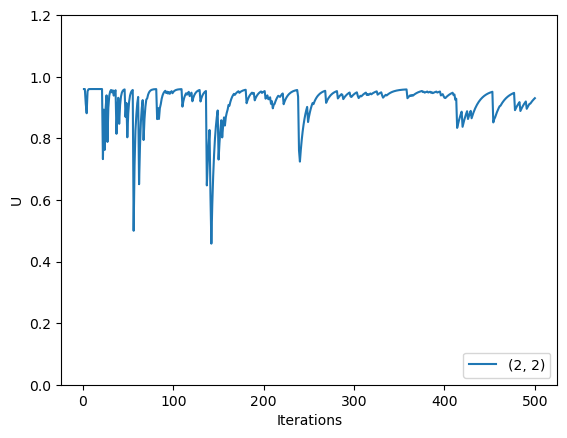

In [27]:
agent = PassiveTDAgent(policy, sequential_decision_environment, alpha=lambda n: 60./(59+n))
graph_utility_estimates(agent, sequential_decision_environment, 500, [(2,2)])

It is also possible to plot multiple states on the same plot. As expected, the utility of the finite state $(3,2)$ stays constant and is equal to $R((3,2)) = 1$.

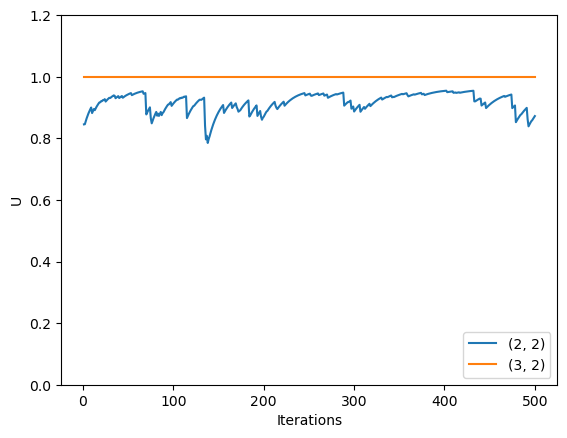

In [25]:
graph_utility_estimates(agent, sequential_decision_environment, 500, [(2,2), (3,2)])

## APRENDIZAGEM POR REFORÇO ATIVO

Ao contrário da Aprendizagem por Reforço Passivo na Aprendizagem por Reforço Ativo, não estamos vinculados a uma política $\pi$ e precisamos de selecionar as nossas ações.

Por outras palavras, o agente precisa de aprender uma política ótima.

O *trade-off* fundamental que o agente necessita de enfrentar é o da **exploração** versus **aproveitamento**.

### Agente QLearning

A classe `QLearningAgent` no módulo rl implementa o Programa Agente descrito.

No *Q-Learning*, o agente aprende uma função de valor de ação $Q$ que fornece a utilidade de tomar uma determinada ação num estado particular.

O *Q-Learning* não requer um modelo de transição e, por isso, é um **método livre de modelos**.

Vamos dar uma vista de olhos à fonte antes de ver alguns exemplos de utilização.

In [ ]:
%psource QLearningAgent


 O Programa Agente pode ser obtido criando a instância da classe passando os parâmetros apropriados.
 
 Devido ao método __ call __, o objeto criado comporta-se como um chamável e devolve uma ação apropriada, como faz a maioria dos Programas de Agente.
 
 Para instanciar o objeto, necessitamos de um `mdp` semelhante ao `PassiveTDAgent`.

 Vamos utilizar o mesmo objeto `GridMDP` que utilizámos acima.
 
 O `sequential_decision_environment` é semelhante ao anteror, mas tem algum desconto, uma vez que $\gamma = 0.9$.
 
 A classe implementa também uma função de exploração $f$ que retorna $R^+$ fixo até que o agente tenha visitado o estado/ação $N_e$ número de vezes.
 
 O método `actions_in_state` devolve ações possíveis num determinado estado. É útil quando se aplicam operações $\max$ e $\argmax$.

 Vamos criar o nosso objeto agora. Também utilizámos o mesmo $\alpha$ definido atrás. Utilizamos $R^+ = 2$ e $N_e = 5$.

In [28]:
q_agent = QLearningAgent(sequential_decision_environment, Ne=5, Rplus=2, 
                         alpha=lambda n: 60./(59+n))

Agora, para testar o q_agent, utilizámos a função `run_single_trial` no rl.py (que também foi utilizada acima).

Vamos fazer **200** iterações.

In [29]:
for i in range(200):
    run_single_trial(q_agent,sequential_decision_environment)

Vamos agora ver os valores Q. As chaves são pares estado-acção. Onde correspondem diferentes ações de acordo com:

- north = (0, 1)

- south = (0,-1)

- west = (-1, 0)

- east = (1, 0)

In [30]:
q_agent.Q

defaultdict(float,
            {((0, 0), (1, 0)): -0.14929294819805294,
             ((0, 0), (0, 1)): 0.5413012187614721,
             ((0, 0), (-1, 0)): -0.14910760880910137,
             ((0, 0), (0, -1)): -0.1531714429585926,
             ((1, 0), (1, 0)): 0.7765870007835873,
             ((1, 0), (0, 1)): -0.11491419905818501,
             ((1, 0), (-1, 0)): -0.07999993704515122,
             ((1, 0), (0, -1)): -0.11567144295859261,
             ((2, 0), (1, 0)): -0.07636363636363636,
             ((2, 0), (0, 1)): 0.5289322471310666,
             ((2, 0), (-1, 0)): -0.08,
             ((2, 0), (0, -1)): -0.11409084613606031,
             ((3, 0), (1, 0)): -0.04,
             ((3, 0), (0, 1)): -1.0090940854792787,
             ((3, 0), (-1, 0)): -0.8573941834221082,
             ((3, 0), (0, -1)): 0.0,
             ((3, 1), None): -0.34419855174386876,
             ((0, 1), (1, 0)): -0.1844017264561602,
             ((0, 1), (0, 1)): 0.5605663565857163,
             ((0, 1), (-1, 

A utilidade **U** de cada estado está relacionada com **Q** pela seguinte equação.

$U (s) = \max_a Q(s, a)$

Vamos converter os valores de Q acima referidos em estimativas U.



In [31]:
U = defaultdict(lambda: -1000.) # Very Large Negative Value for Comparison see below.
for state_action, value in q_agent.Q.items():
    state, action = state_action
    if U[state] < value:
                U[state] = value

In [32]:
U

defaultdict(<function __main__.<lambda>()>,
            {(0, 0): 0.5413012187614721,
             (1, 0): 0.7765870007835873,
             (2, 0): 0.5289322471310666,
             (3, 0): 0.0,
             (3, 1): -0.34419855174386876,
             (0, 1): 0.5605663565857163,
             (0, 2): 0.5768106538798488,
             (1, 2): 0.5814185220886952,
             (2, 2): 0.5970390972008914,
             (2, 1): 0.5595983882376235,
             (3, 2): 0.6054290688822335})

Finalmente, vamos comparar estas estimativas com os resultados do `value_iteration`.

In [34]:
value_iteration(sequential_decision_environment)

{(0, 1): 0.7615582191780823,
 (1, 2): 0.8678082191780823,
 (2, 1): 0.6602739726027398,
 (0, 0): 0.7053082191780823,
 (3, 1): -1.0,
 (2, 0): 0.6114155251141552,
 (3, 0): 0.38792491121258244,
 (0, 2): 0.8115582191780822,
 (2, 2): 0.9178082191780822,
 (1, 0): 0.6553082191780822,
 (3, 2): 1.0}